<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-3/DeepLearning_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1846s 11us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Testing images shape  : (10000, 32, 32, 3)
Testing labels shape  : (10000, 1)
Number of classes     : 10
Image size            : (32, 32, 3) 



/tmp/ipykernel_3408/3163952651.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASS_NAMES[int(y_train[i])])


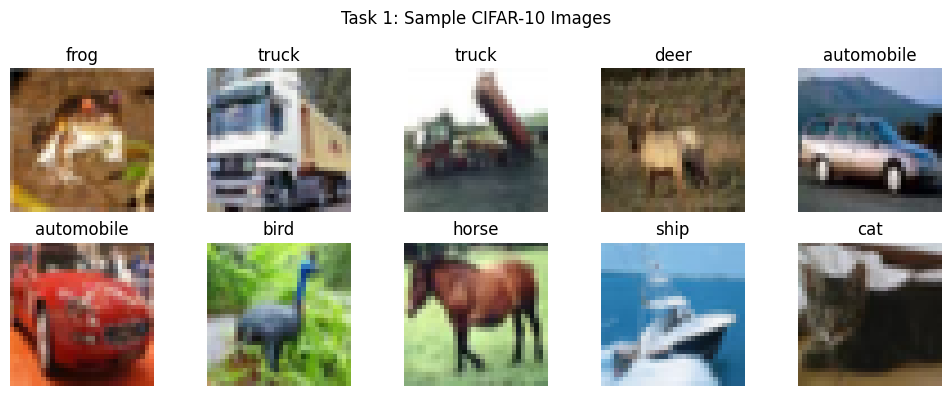

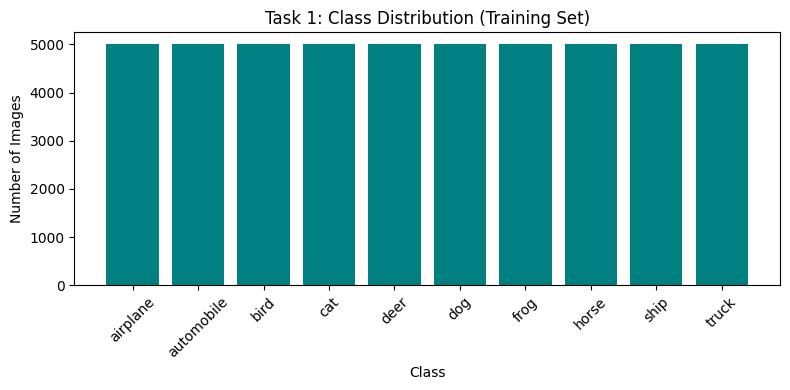

In [2]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 1: Load CIFAR-10 dataset

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ----------------------------------------------------------------
# Load CIFAR-10
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# ----------------------------------------------------------------
# Print dataset dimensions
# ----------------------------------------------------------------
print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)
print("Number of classes     :", len(np.unique(y_train)))
print("Image size            :", x_train.shape[1:], "\n")

# ----------------------------------------------------------------
# Display ten sample images
# ----------------------------------------------------------------
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[int(y_train[i])])
    plt.axis('off')
plt.suptitle("Task 1: Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("task1_sample_images.png")
plt.show()

# ----------------------------------------------------------------
# Plot class distribution
# ----------------------------------------------------------------
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='teal')
plt.xticks(rotation=45)
plt.title("Task 1: Class Distribution (Training Set)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("task1_class_distribution.png")
plt.show()

Input image shape: (32, 32, 3) 

--- Task 2: Kernel Size Comparison ---
Kernel 3x3 -> Output feature map shape: (30, 30, 8)
Kernel 5x5 -> Output feature map shape: (28, 28, 8)
Kernel 7x7 -> Output feature map shape: (26, 26, 8)

--- Verification using formula (N-F+2P)/S + 1 ---
Kernel 3x3 -> Formula gives: 30x30
Kernel 5x5 -> Formula gives: 28x28
Kernel 7x7 -> Formula gives: 26x26


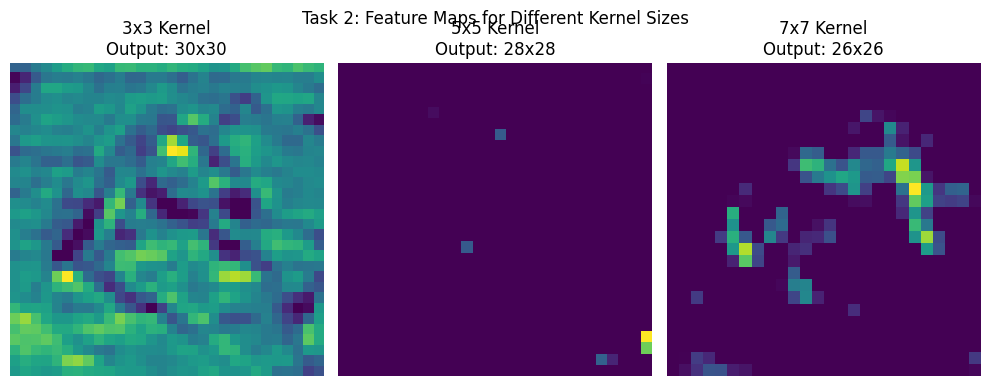


--- Summary ---
Kernel Size    Output Feature Map Size  
3x3            (30, 30, 8)              
5x5            (28, 28, 8)              
7x7            (26, 26, 8)              


In [3]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 2: Implement a convolution layer and compare kernel sizes

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ----------------------------------------------------------------
# Load CIFAR-10 (just to get a sample image to convolve over)
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train.astype('float32') / 255.0

sample_img = x_train_norm[0:1]   # shape (1, 32, 32, 3)
print("Input image shape:", sample_img.shape[1:], "\n")

# ----------------------------------------------------------------
# Implement convolution layers with different kernel sizes
# ----------------------------------------------------------------
kernel_sizes = [3, 5, 7]
results = {}
feature_maps = {}

print("--- Task 2: Kernel Size Comparison ---")
for k in kernel_sizes:
    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=k,
        strides=1,
        padding='valid',
        activation='relu'
    )
    output = conv_layer(sample_img)
    results[k] = output.shape[1:]
    feature_maps[k] = output.numpy()
    print(f"Kernel {k}x{k} -> Output feature map shape: {output.shape[1:]}")

# ----------------------------------------------------------------
# Verify against the formula: (N - F + 2P) / S + 1
# ----------------------------------------------------------------
print("\n--- Verification using formula (N-F+2P)/S + 1 ---")
N, P, S = 32, 0, 1  # input size, padding (valid=0), stride
for k in kernel_sizes:
    computed = (N - k + 2 * P) // S + 1
    print(f"Kernel {k}x{k} -> Formula gives: {computed}x{computed}")

# ----------------------------------------------------------------
# Visualize one feature map per kernel size for comparison
# ----------------------------------------------------------------
plt.figure(figsize=(10, 4))
for i, k in enumerate(kernel_sizes):
    plt.subplot(1, 3, i + 1)
    plt.imshow(feature_maps[k][0, :, :, 0], cmap='viridis')
    plt.title(f"{k}x{k} Kernel\nOutput: {results[k][0]}x{results[k][1]}")
    plt.axis('off')
plt.suptitle("Task 2: Feature Maps for Different Kernel Sizes")
plt.tight_layout()
plt.savefig("task2_kernel_comparison.png")
plt.show()

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
print("\n--- Summary ---")
print(f"{'Kernel Size':<15}{'Output Feature Map Size':<25}")
for k in kernel_sizes:
    print(f"{f'{k}x{k}':<15}{str(results[k]):<25}")

Input image shape: (32, 32, 3) 

--- Stride Comparison (Kernel=3x3, Padding=valid) ---
Stride=1 -> Output shape: (30, 30, 8)
Stride=2 -> Output shape: (15, 15, 8)

--- Padding Comparison (Kernel=3x3, Stride=1) ---
Padding=same -> Output shape: (32, 32, 8)
Padding=valid -> Output shape: (30, 30, 8)

--- Verification using formula (N-F+2P)/S + 1 ---
Stride=1, Padding=valid -> Formula gives: 30x30
Stride=2, Padding=valid -> Formula gives: 15x15
Padding=same, Stride=1  -> Output equals input size: 32x32 (Keras auto-pads with P = 1)
Padding=valid, Stride=1 -> Formula gives: 30x30


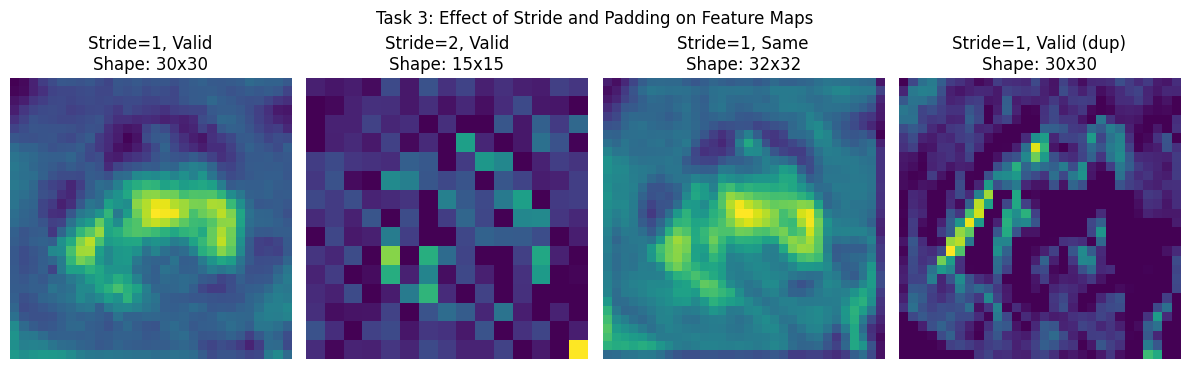


--- Summary ---
Configuration                 Output Shape        
Stride=1, Padding=valid       (30, 30, 8)         
Stride=2, Padding=valid       (15, 15, 8)         
Stride=1, Padding=same        (32, 32, 8)         
Stride=1, Padding=valid       (30, 30, 8)         


In [4]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 3: Study hyperparameters (Stride and Padding)

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# ----------------------------------------------------------------
# Load CIFAR-10 (just to get a sample image to convolve over)
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train.astype('float32') / 255.0

sample_img = x_train_norm[0:1]   # shape (1, 32, 32, 3)
N = sample_img.shape[1]          # input size = 32
print("Input image shape:", sample_img.shape[1:], "\n")

# ----------------------------------------------------------------
# Compare Stride = 1 vs Stride = 2  (fixed padding = 'valid')
# ----------------------------------------------------------------
print("--- Stride Comparison (Kernel=3x3, Padding=valid) ---")
stride_results = {}
stride_feature_maps = {}

for s in [1, 2]:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3, strides=s,
                                padding='valid', activation='relu')
    output = conv_layer(sample_img)
    stride_results[s] = output.shape[1:]
    stride_feature_maps[s] = output.numpy()
    print(f"Stride={s} -> Output shape: {output.shape[1:]}")

# ----------------------------------------------------------------
# Compare Padding = 'same' vs Padding = 'valid'  (fixed stride = 1)
# ----------------------------------------------------------------
print("\n--- Padding Comparison (Kernel=3x3, Stride=1) ---")
padding_results = {}
padding_feature_maps = {}

for p in ['same', 'valid']:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3, strides=1,
                                padding=p, activation='relu')
    output = conv_layer(sample_img)
    padding_results[p] = output.shape[1:]
    padding_feature_maps[p] = output.numpy()
    print(f"Padding={p} -> Output shape: {output.shape[1:]}")

# ----------------------------------------------------------------
# Verify against the formula: (N - F + 2P) / S + 1
# For 'same' padding with stride 1, output size = input size (Keras pads automatically)
# For 'valid' padding, P = 0
# ----------------------------------------------------------------
F = 3
print("\n--- Verification using formula (N-F+2P)/S + 1 ---")

for s in [1, 2]:
    P = 0  # valid padding
    computed = (N - F + 2 * P) // s + 1
    print(f"Stride={s}, Padding=valid -> Formula gives: {computed}x{computed}")

print(f"Padding=same, Stride=1  -> Output equals input size: {N}x{N} "
      f"(Keras auto-pads with P = {(F - 1) // 2})")
print(f"Padding=valid, Stride=1 -> Formula gives: {(N - F + 0)//1 + 1}x{(N - F + 0)//1 + 1}")

# ----------------------------------------------------------------
# Visualize feature maps for all four configurations
# ----------------------------------------------------------------
configs = [
    ("Stride=1, Valid", stride_feature_maps[1]),
    ("Stride=2, Valid", stride_feature_maps[2]),
    ("Stride=1, Same",  padding_feature_maps['same']),
    ("Stride=1, Valid (dup)", padding_feature_maps['valid']),
]

plt.figure(figsize=(12, 4))
for i, (title, fmap) in enumerate(configs):
    plt.subplot(1, 4, i + 1)
    plt.imshow(fmap[0, :, :, 0], cmap='viridis')
    plt.title(f"{title}\nShape: {fmap.shape[1]}x{fmap.shape[2]}")
    plt.axis('off')
plt.suptitle("Task 3: Effect of Stride and Padding on Feature Maps")
plt.tight_layout()
plt.savefig("task3_stride_padding_comparison.png")
plt.show()

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
print("\n--- Summary ---")
print(f"{'Configuration':<30}{'Output Shape':<20}")
print(f"{'Stride=1, Padding=valid':<30}{str(stride_results[1]):<20}")
print(f"{'Stride=2, Padding=valid':<30}{str(stride_results[2]):<20}")
print(f"{'Stride=1, Padding=same':<30}{str(padding_results['same']):<20}")
print(f"{'Stride=1, Padding=valid':<30}{str(padding_results['valid']):<20}")

Sample image class: frog


/tmp/ipykernel_3408/767260495.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Sample image class:", CLASS_NAMES[int(y_train[0])])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Feature map tensor shape: (1, 32, 32, 32)
Number of filters (channels) in conv1: 32


/tmp/ipykernel_3408/767260495.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Original Image\n({CLASS_NAMES[int(y_train[0])]})")


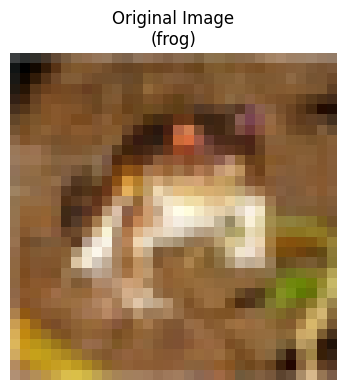

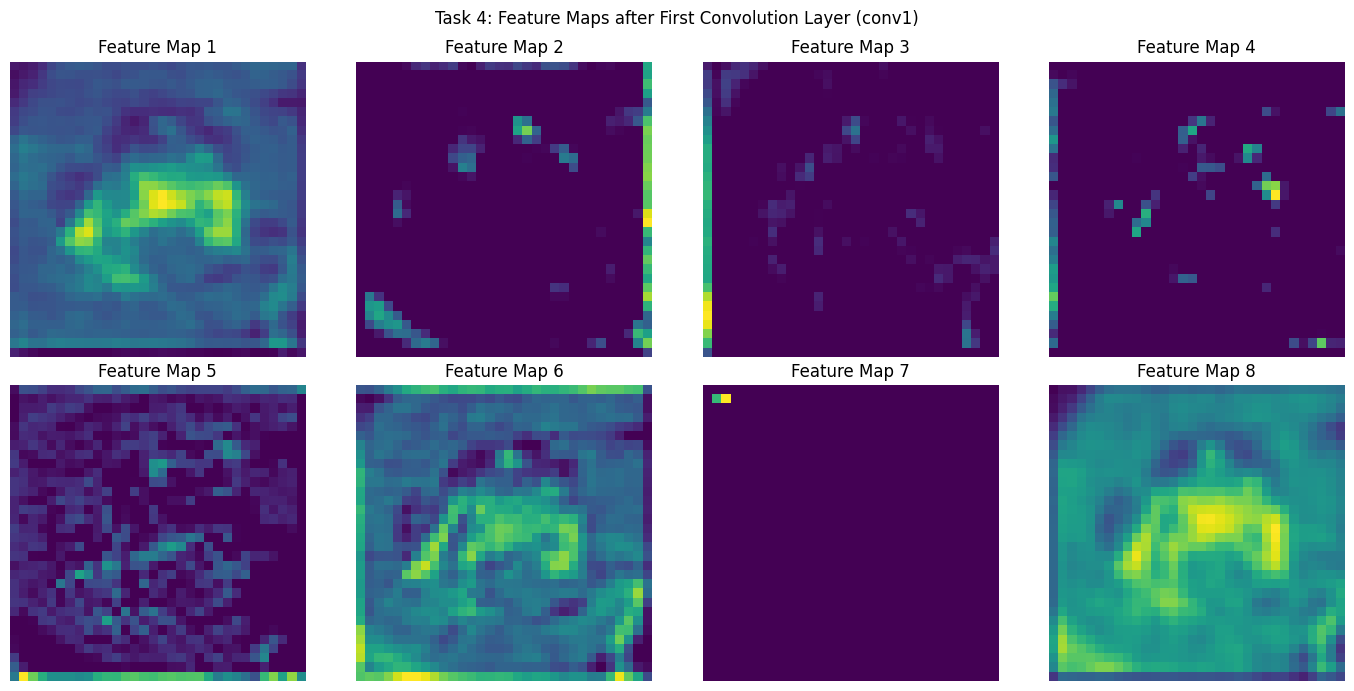

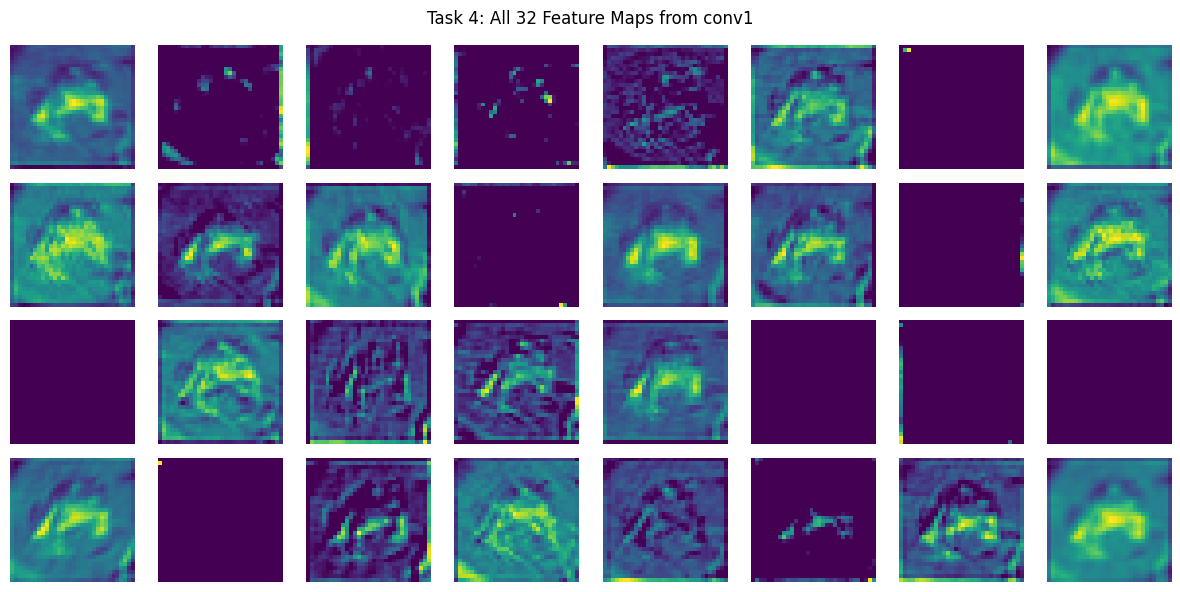

In [6]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 4: Visualize feature maps after the first convolution layer

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ----------------------------------------------------------------
# Load CIFAR-10
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train.astype('float32') / 255.0

sample_img = x_train_norm[0:1]   # shape (1, 32, 32, 3)
print("Sample image class:", CLASS_NAMES[int(y_train[0])])

# ----------------------------------------------------------------
# Build a CNN (Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> ...)
# ----------------------------------------------------------------
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.summary()

# ----------------------------------------------------------------
# Extract output of the FIRST convolution layer ('conv1')
# ----------------------------------------------------------------
feature_extractor = models.Model(inputs=model.inputs,
                                  outputs=model.get_layer('conv1').output)
feature_maps = feature_extractor.predict(sample_img)

print("\nFeature map tensor shape:", feature_maps.shape)
print(f"Number of filters (channels) in conv1: {feature_maps.shape[-1]}")

# ----------------------------------------------------------------
# Display the original image alongside at least 8 feature maps
# ----------------------------------------------------------------
num_maps_to_show = 8

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0])
plt.title(f"Original Image\n({CLASS_NAMES[int(y_train[0])]})")
plt.axis('off')
plt.tight_layout()
plt.savefig("task4_original_image.png")
plt.show()

plt.figure(figsize=(14, 7))
for i in range(num_maps_to_show):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Feature Map {i + 1}")
    plt.axis('off')
plt.suptitle("Task 4: Feature Maps after First Convolution Layer (conv1)")
plt.tight_layout()
plt.savefig("task4_feature_maps.png")
plt.show()

# ----------------------------------------------------------------
# Optional: display ALL filters from conv1 in a grid (32 filters)
# ----------------------------------------------------------------
total_filters = feature_maps.shape[-1]
cols = 8
rows = int(np.ceil(total_filters / cols))

plt.figure(figsize=(cols * 1.5, rows * 1.5))
for i in range(total_filters):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f"Task 4: All {total_filters} Feature Maps from conv1")
plt.tight_layout()
plt.savefig("task4_all_feature_maps.png")
plt.show()

--- Part A: Output Size Comparison (2x2 pooling, stride 2) ---
Input to pooling layer: (32, 32, 32)
After MaxPooling2D(2x2)     -> Output shape: (16, 16, 32)
After AveragePooling2D(2x2) -> Output shape: (16, 16, 32)
(Max and Average pooling always give the SAME output size for the same pool size/stride — they differ in the VALUES they compute, not the shape.)

--- Part B: Accuracy Comparison ---

Training CNN with Max Pooling...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.4998 - loss: 1.3953 - val_accuracy: 0.5882 - val_loss: 1.1735
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.6426 - loss: 1.0189 - val_accuracy: 0.6572 - val_loss: 0.9817
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.6944 - loss: 0.8752 - val_accuracy: 0.6794 - val_loss: 0.9169
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 146s 61ms/step - accuracy: 0.7306 - loss: 0.7710 - val_accuracy: 0.6890 - val_loss: 0.9031
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━

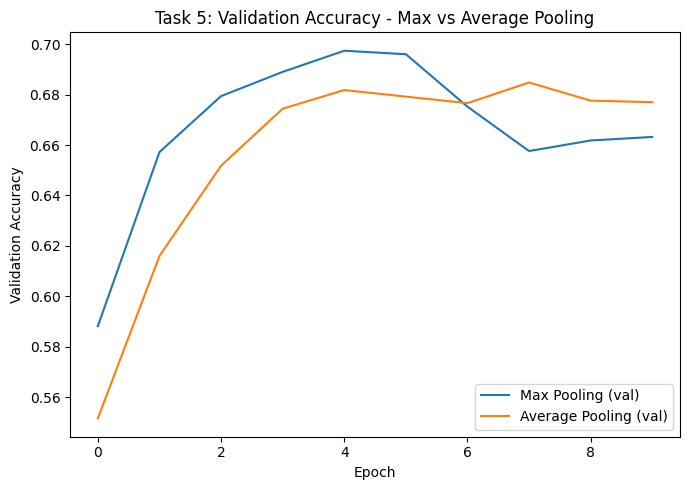


--- Summary ---
Pooling Type   Output Shape        Test Accuracy  Test Loss 
Max            (16, 16, 32)        0.6541         1.4303    
Average        (16, 16, 32)        0.6658         1.1421    


In [7]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 5: Compare Max Pooling vs Average Pooling

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ----------------------------------------------------------------
# Load and prepare CIFAR-10
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

sample_img = x_train_norm[0:1]

# ----------------------------------------------------------------
# Part A: Compare OUTPUT SIZE of Max Pooling vs Average Pooling
# ----------------------------------------------------------------
print("--- Part A: Output Size Comparison (2x2 pooling, stride 2) ---")

conv_out = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(sample_img)
print(f"Input to pooling layer: {conv_out.shape[1:]}")

max_pool_out = layers.MaxPooling2D((2, 2))(conv_out)
avg_pool_out = layers.AveragePooling2D((2, 2))(conv_out)

print(f"After MaxPooling2D(2x2)     -> Output shape: {max_pool_out.shape[1:]}")
print(f"After AveragePooling2D(2x2) -> Output shape: {avg_pool_out.shape[1:]}")
print("(Max and Average pooling always give the SAME output size for the same "
      "pool size/stride — they differ in the VALUES they compute, not the shape.)\n")

# ----------------------------------------------------------------
# Part B: Compare ACCURACY - build two identical CNNs differing
# only in the pooling layer type
# ----------------------------------------------------------------
def build_model(pool_type='max'):
    Pool = layers.MaxPooling2D if pool_type == 'max' else layers.AveragePooling2D
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        Pool((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        Pool((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

print("--- Part B: Accuracy Comparison ---")
histories = {}
results = {}

for ptype in ['max', 'average']:
    print(f"\nTraining CNN with {ptype.capitalize()} Pooling...")
    model = build_model(ptype)
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy'])
    hist = model.fit(x_train_norm, y_train_cat, epochs=10, batch_size=32,
                      validation_split=0.1, verbose=1)
    test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)

    histories[ptype] = hist
    results[ptype] = {"test_loss": test_loss, "test_acc": test_acc}
    print(f"{ptype.capitalize()} Pooling -> Test Accuracy: {test_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}")

# ----------------------------------------------------------------
# Plot training/validation accuracy curves for both pooling types
# ----------------------------------------------------------------
plt.figure(figsize=(7, 5))
for ptype, color in zip(['max', 'average'], ['tab:blue', 'tab:orange']):
    plt.plot(histories[ptype].history['val_accuracy'],
              label=f'{ptype.capitalize()} Pooling (val)', color=color)
plt.title("Task 5: Validation Accuracy - Max vs Average Pooling")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("task5_pooling_accuracy_comparison.png")
plt.show()

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
print("\n--- Summary ---")
print(f"{'Pooling Type':<15}{'Output Shape':<20}{'Test Accuracy':<15}{'Test Loss':<10}")
print(f"{'Max':<15}{str(max_pool_out.shape[1:]):<20}"
      f"{results['max']['test_acc']:<15.4f}{results['max']['test_loss']:<10.4f}")
print(f"{'Average':<15}{str(avg_pool_out.shape[1:]):<20}"
      f"{results['average']['test_acc']:<15.4f}{results['average']['test_loss']:<10.4f}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 545098
Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 59ms/step - accuracy: 0.4850 - loss: 1.4375 - val_accuracy: 0.5874 - val_loss: 1.1840
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.6336 - loss: 1.0462 - val_accuracy: 0.6430 - val_loss: 1.0195
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - accuracy: 0.6865 - loss: 0.9025 - val_accuracy: 0.6740 - val_loss: 0.9435
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 86s 61ms/step - accuracy: 0.7194 - loss: 0.8058 - val_accuracy: 0.6870 - val_loss: 0.9251
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 139s 59ms/step - accuracy: 0.7468 - loss: 0.7268 - val_accuracy: 0.6888 - val_loss: 0.9291
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - accuracy: 0.7750 - loss: 0.6516 - val_accuracy: 0.6904 - val_loss: 0.9523
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 143s 59ms/step - accuracy: 0.7998 - loss: 0.5808 - val_accuracy: 0.6924 - val_loss: 0.9866
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━

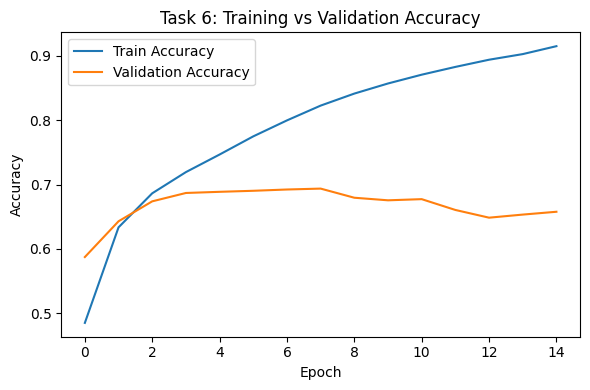

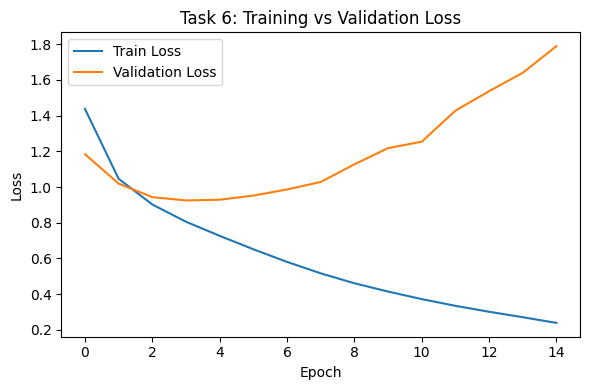


Model saved as task6_cnn_model.keras


In [8]:
"""
CS3807 - Deep Learning Laboratory
Experiment 3 - Task 6: Construct the CNN and Train it

Architecture:
Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax

Training:
Optimizer = Adam, Epochs = 20, Batch Size = 32

Requires: tensorflow, numpy, matplotlib
    pip install tensorflow numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------------------------------------------
# Load and prepare CIFAR-10
# ----------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# ==================================================================
# Construct the CNN
# Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax
# ==================================================================
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()
print("\nTotal trainable parameters:", model.count_params())

# ----------------------------------------------------------------
# Compile with Adam optimizer
# ----------------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------------------------------------------
# Train: Epochs = 15, Batch Size = 32
# ----------------------------------------------------------------
history = model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    verbose=1
)

# ----------------------------------------------------------------
# Evaluate on test set (basic check)
# ----------------------------------------------------------------
test_loss, test_acc = model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss    : {test_loss:.4f}")

# ----------------------------------------------------------------
# Plot training/validation accuracy and loss
# ----------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Task 6: Training vs Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout()
plt.savefig("task6_accuracy.png")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Task 6: Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.savefig("task6_loss.png")
plt.show()

# Save the trained model for later use (e.g., in Task 7 evaluation)
model.save("task6_cnn_model.keras")
print("\nModel saved as task6_cnn_model.keras")


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step
Test Accuracy   : 0.6519
Precision(macro): 0.6573
Recall(macro)   : 0.6519
F1-score(macro) : 0.6499

              precision    recall  f1-score   support

    airplane       0.67      0.69      0.68      1000
  automobile       0.86      0.67      0.75      1000
        bird       0.55      0.55      0.55      1000
         cat       0.52      0.41      0.46      1000
        deer       0.54      0.70      0.61      1000
         dog       0.59      0.53      0.56      1000
        frog       0.75      0.65      0.70      1000
       horse       0.66      0.74      0.70      1000
        ship       0.67      0.86      0.75      1000
       truck       0.77      0.73      0.75      1000

    accuracy                           0.65     10000
   macro avg       0.66      0.65      0.65     10000
weighted avg       0.66      0.65      0.65     10000



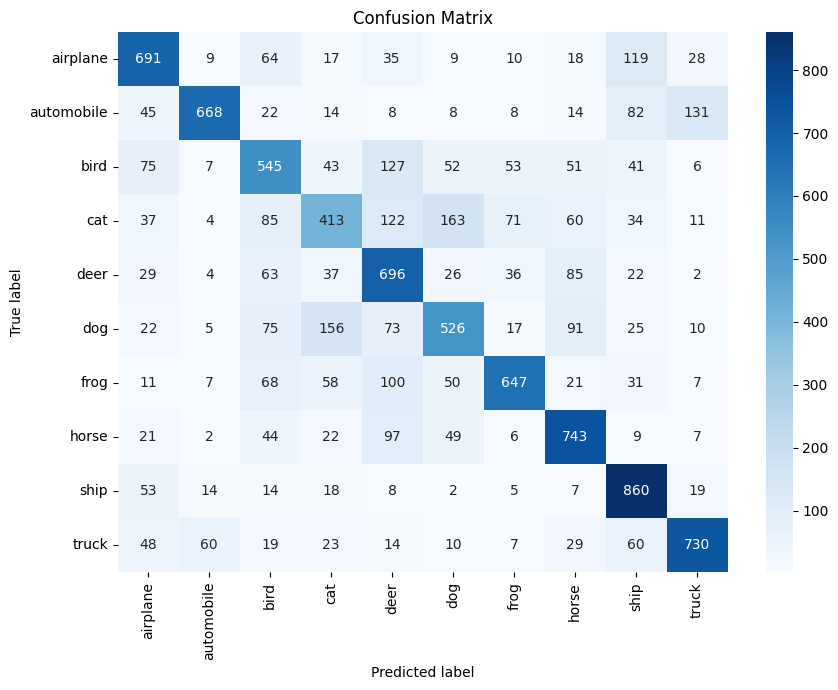

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

# Get predictions on the test set
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Core metrics ---
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy   : {acc:.4f}")
print(f"Precision(macro): {prec:.4f}")
print(f"Recall(macro)   : {rec:.4f}")
print(f"F1-score(macro) : {f1:.4f}")
print()

# --- Classification Report (per-class precision/recall/F1) ---
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(classification_report(y_test, y_pred, target_names=class_names))

# --- Confusion Matrix (Mandatory Plot 8) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plot8_confusion_matrix.png', dpi=150)
plt.show()

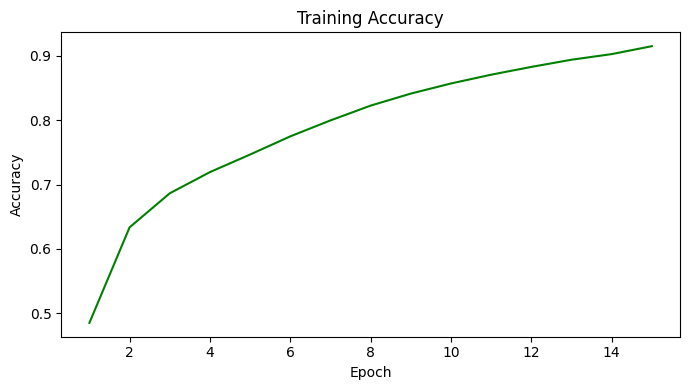

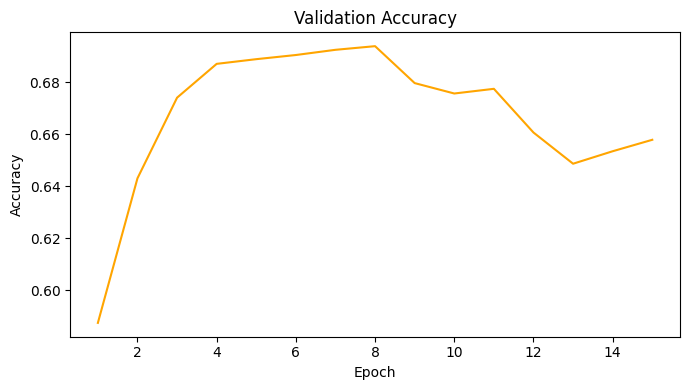

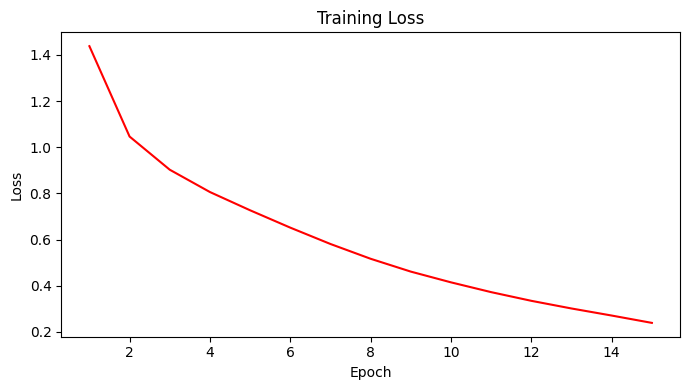

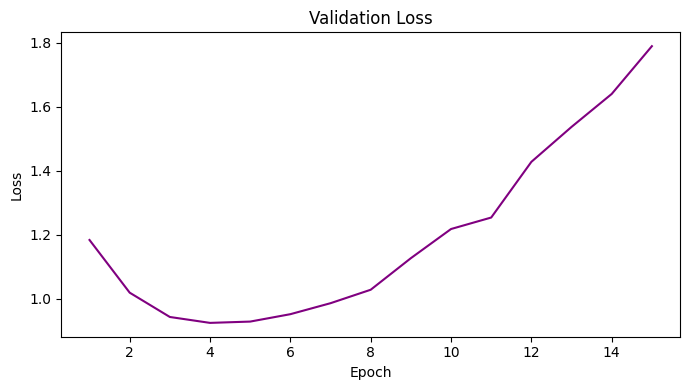

In [11]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Plot 3: Training Accuracy
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history['accuracy'], color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training Accuracy')
plt.tight_layout(); plt.savefig('plot3_training_accuracy.png', dpi=150); plt.show()

# Plot 4: Validation Accuracy
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history['val_accuracy'], color='orange')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy')
plt.tight_layout(); plt.savefig('plot4_validation_accuracy.png', dpi=150); plt.show()

# Plot 5: Training Loss
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history['loss'], color='red')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.savefig('plot5_training_loss.png', dpi=150); plt.show()

# Plot 6: Validation Loss
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history['val_loss'], color='purple')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Validation Loss')
plt.tight_layout(); plt.savefig('plot6_validation_loss.png', dpi=150); plt.show()